In [1]:
# Cell 1: Imports and Setup
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import time # To add slight delay if needed for multiple initializations

# --- IMPORTANT: Adjust this path if necessary ---
# Add the project root directory to the Python path
# This assumes your notebook is run from a location where this relative path works,
# or you can provide an absolute path.
try:
    # Assumes notebook is in a 'notebooks' folder sibling to 'src'
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback if __file__ is not defined (e.g., interactive environment)
    # Adjust this path to your project root containing the 'src' folder
    project_root = r"C:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Example absolute path

if project_root not in sys.path:
    print(f"Adding project root to sys.path: {project_root}")
    sys.path.append(project_root)
# --- End Path Setup ---

# Now import the samplers using the specified path
try:
    # from src.tasks.envs.function_envs.function_samplers import AckleySampler, CosineSampler, PolySampler, FunctionSampler, 
    from src.tasks.envs.function_envs.sampling_functions.gp_sampler import GPSampler
    from src.tasks.envs.function_envs.sampling_functions.eggholder_sampler import EggholderSamplerND
    from src.tasks.envs.function_envs.sampling_functions.rosenbrock_sampler import RosenbrockSampler
    from src.tasks.envs.function_envs.sampling_functions.michalewicz_sampler import MichalewiczSampler
    from src.tasks.envs.function_envs.sampling_functions.hartmann_sampler import Hartmann6Sampler
    from src.tasks.envs.function_envs.sampling_functions.branin_sampler import BraninSampler
    from src.tasks.envs.function_envs.sampling_functions.ackley_sampler import AckleySampler
    from src.tasks.envs.function_envs.sampling_functions.cosine_sampler import CosineSampler
    from src.tasks.envs.function_envs.sampling_functions.poly_sampler import PolySampler
    from src.tasks.envs.function_envs.sampling_functions.base_sampler import FunctionSampler
    
    print("Samplers imported successfully.")
except ImportError as e:
    print(f"Error importing samplers: {e}")
    print("Please ensure the project root path is correct and the samplers file exists at:")
    print("src/tasks/envs/function_envs/function_samplers.py")
# Matplotlib style settings (optional)
plt.style.use('seaborn-v0_8-whitegrid')

Adding project root to sys.path: C:\Users\jimvo\Documents\Recurrent-PPO-Jax
Samplers imported successfully.


In [2]:
# Cell 2: Plotting Functions (Corrected)

def plot_sampler_instance(sampler_class, sampler_config, title, resolution=100, seed=None):
    """
    Plots a single instance of a function generated by a sampler.
    Handles both 1D and 2D based on sampler_config['action_dim'].
    """
    if not issubclass(sampler_class, FunctionSampler):
         raise TypeError("sampler_class must be a subclass of FunctionSampler")

    action_dim = sampler_config.get("action_dim", None)
    x_range = sampler_config.get("bounds", None)
    print(sampler_config)
    print(action_dim, x_range)
    if action_dim is None or x_range is None:
        raise ValueError("sampler_config must contain 'action_dim' and 'bounds'")

    # --- Instantiate and Initialize Sampler ---
    if seed is not None:
        np.random.seed(seed) # Set seed for reproducibility of this instance

    # Create config specific to the sampler (action_dim, x_range, and optional overrides)
    sampler_init_config = {
        key: val for key, val in sampler_config.items()
        if key not in ['action_dim', 'bounds'] # Pass only sampler-specific params
    }
    

    sampler = sampler_class(action_dim=action_dim, x_range=x_range, config=sampler_init_config)
    optimum_point, min_y, max_y = sampler.initialize()
    optimum_point = np.array(optimum_point).reshape(1, -1)
    print(f"Initialized {sampler_class.__name__}: Optimum={optimum_point}, MinY={min_y:.3f}, MaxY={max_y:.3f}")

    # --- Generate Plotting Grid ---
    lower, upper = x_range
    if action_dim == 1:
        # x_plot needs shape (resolution,) for plotting
        x_plot = np.linspace(lower, upper, resolution)
        # Pass x_plot reshaped to (resolution, 1) to compute_y
        y_plot = sampler.compute_y(x_plot.reshape(-1, 1))
        # Ensure y_plot is also 1D for plotting
        y_plot = np.squeeze(y_plot)
        if y_plot.shape != x_plot.shape:
            # Handle scalar case if compute_y somehow returned a single value unexpectedly
             print(f"Warning: y_plot shape {y_plot.shape} unexpected, attempting to broadcast.")
             y_plot = np.full(x_plot.shape, y_plot.item()) # Attempt to fix if scalar

    elif action_dim == 2:
        x1 = np.linspace(lower, upper, resolution)
        x2 = np.linspace(lower, upper, resolution)
        # x1 = np.linspace(-5, 10, resolution)
        # x2 = np.linspace(0, 15, resolution)
        X1, X2 = np.meshgrid(x1, x2)
        # Stack into format expected by compute_y: (resolution*resolution, 2)
        x_plot_flat = np.vstack([X1.ravel(), X2.ravel()]).T
        y_plot_flat = sampler.compute_y(x_plot_flat)
        Y = y_plot_flat.reshape(X1.shape) # Reshape back to grid
    else:
        print(f"Plotting only supported for 1D and 2D. Skipping plot for dim={action_dim}.")
        return

    # --- Create Plot ---
    fig = plt.figure(figsize=(10, 8))
    if action_dim == 1:
        ax = fig.add_subplot(111)
        # Check shapes before plotting
        if x_plot.shape != y_plot.shape:
             raise ValueError(f"Corrected plot error: x_plot shape {x_plot.shape} and y_plot shape {y_plot.shape} still don't match!")
        ax.plot(x_plot, y_plot, label=f'{sampler_class.__name__} Instance')
        # Plot optimum point if available
        if optimum_point is not None:
             # Ensure optimum_point is indexable even if 1D
             opt_x = optimum_point[0] #if isinstance(optimum_point, (np.ndarray, list, tuple)) and len(optimum_point) > 0 else optimum_point
             ax.plot(opt_x, max_y, 'ro', markersize=8, label=f'Optimum ({max_y:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.set_title(f'{title} (1D)')
        ax.legend()
        ax.grid(True)
    elif action_dim == 2:
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.8)
        # Plot optimum point if available
        if optimum_point is not None and len(optimum_point) == 2:
            ax.scatter(optimum_point[0], optimum_point[1], max_y, color='r', s=50, depthshade=True, label=f'Optimum ({max_y:.2f})')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('f(x1, x2)')
        ax.set_title(f'{title} (2D)')
        fig.colorbar(surf, shrink=0.5, aspect=5, label='f(x1, x2)')
        ax.view_init(elev=30, azim=-60) # Adjust view angle if needed
        if optimum_point is not None: ax.legend()


    plt.tight_layout()
    plt.show()


def plot_multiple_sampler_runs(sampler_class, sampler_config, title, num_runs=5, resolution=100):
    """
    Plots multiple instances of a function generated by a sampler on the same axes.
    Only supports 1D plotting.
    """
    if not issubclass(sampler_class, FunctionSampler):
         raise TypeError("sampler_class must be a subclass of FunctionSampler")

    action_dim = sampler_config.get("action_dim", None)
    x_range = sampler_config.get("bounds", None)
    
    print(action_dim, x_range)

    if action_dim is None or x_range is None:
        raise ValueError("sampler_config must contain 'action_dim' and 'bounds'")

    if action_dim != 1:
        print(f"Plotting multiple runs only supported for 1D. Skipping plot for dim={action_dim}.")
        return

    lower, upper = x_range
    # x_plot needs shape (resolution,) for plotting
    x_plot = np.linspace(lower, upper, resolution)
    # Prepare x_plot_input with shape (resolution, 1) for compute_y
    x_plot_input = x_plot.reshape(-1, 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f'{title} - {num_runs} Random Runs (1D)')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)

    all_optima_x = []
    all_optima_y = []

    # Create config specific to the sampler (action_dim, x_range, and optional overrides)
    sampler_init_config = {
        key: val for key, val in sampler_config.items()
        if key not in ['action_dim', 'bounds']
    }

    for i in range(num_runs):
        # Create and initialize a new sampler instance for each run
        sampler = sampler_class(action_dim=action_dim, x_range=x_range, config=sampler_init_config)
        optimum_point, _, max_y = sampler.initialize()
        optimum_point = np.array(optimum_point).reshape(1, -1)

        # Compute values for this instance using correctly shaped input
        y_plot = sampler.compute_y(x_plot_input)
        # Ensure y_plot is 1D for plotting
        y_plot = np.squeeze(y_plot)
        if y_plot.shape != x_plot.shape:
             print(f"Warning: y_plot shape {y_plot.shape} unexpected in multi-run, attempting broadcast.")
             y_plot = np.full(x_plot.shape, y_plot.item())

        # Plot this run
        if x_plot.shape != y_plot.shape:
             print(f"Skipping plot for run {i+1} due to shape mismatch: x={x_plot.shape}, y={y_plot.shape}")
             continue
        ax.plot(x_plot, y_plot, alpha=0.6, label=f'Run {i+1}' if num_runs <= 10 else None) # Avoid too many labels

        # Store optimum
        if optimum_point is not None:
             opt_x = optimum_point[0] if isinstance(optimum_point, (np.ndarray, list, tuple)) and len(optimum_point) > 0 else optimum_point
             all_optima_x.append(opt_x)
             all_optima_y.append(max_y)

        # time.sleep(0.01) # Optional small delay if random seeding needs time

    # Plot all optima
    if all_optima_x:
        ax.scatter(all_optima_x, all_optima_y, color='red', s=30, zorder=5, label='Optima')

    if num_runs <= 10 or not all_optima_x: # Show legend if few runs or only optima plotted
         ax.legend(loc='best')

    plt.tight_layout()
    plt.show()

In [3]:
# Cell 3: Configuration

# --- Standard Configs (modify as needed) ---
base_config_1d = {
    "action_dim": 1,
    "bounds": [-5.0, 5.0], # Example bounds
}

base_config_2d = {
    "action_dim": 2,
    "bounds": [-5.0, 5.0], # Example bounds
}

# --- Sampler Specific Configs (overrides) ---









--- Visualizing Ackley Function ---
{'action_dim': 1, 'bounds': [-5.0, 5.0], 'a_bounds': [18.0, 20.0], 'b_bounds': [0.15, 0.25], 'c_bounds': [6.0, 7.0]}
1 [-5.0, 5.0]
Initialized AckleySampler: Optimum=[[0.59195091]], MinY=-14.258, MaxY=0.000


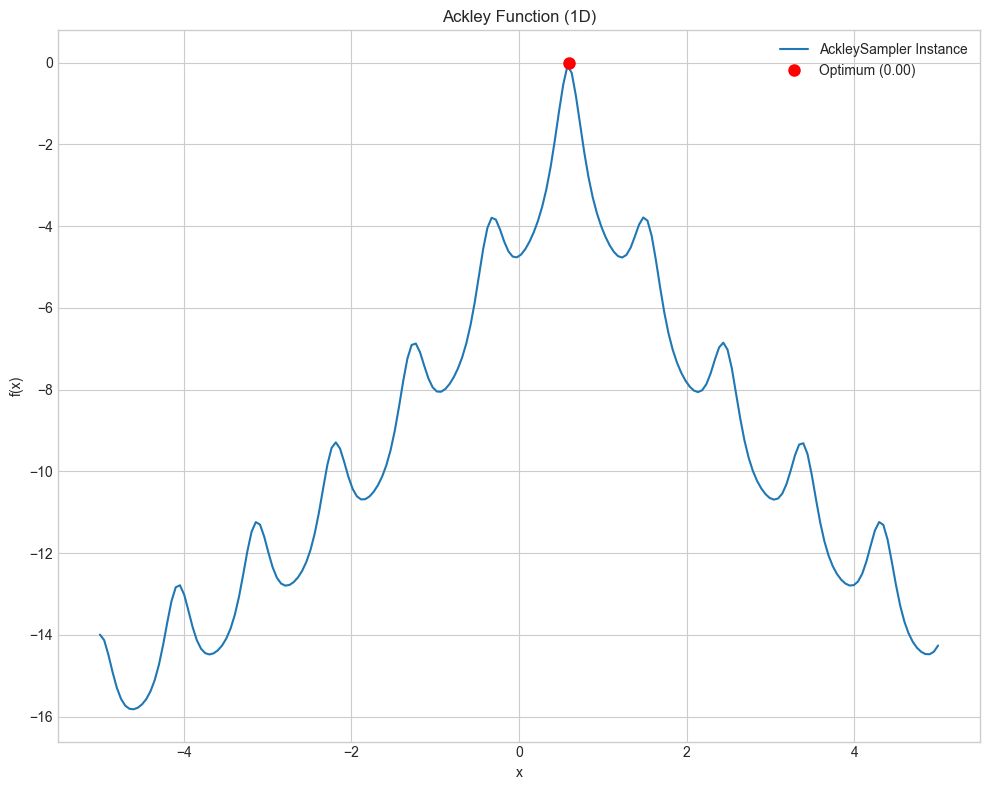

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'action_dim': 2, 'bounds': [-5.0, 5.0], 'a_bounds': [18.0, 20.0], 'b_bounds': [0.15, 0.25], 'c_bounds': [6.0, 7.0]}
2 [-5.0, 5.0]
Initialized AckleySampler: Optimum=[[ 0.59195091 -2.06388816]], MinY=-16.487, MaxY=0.000


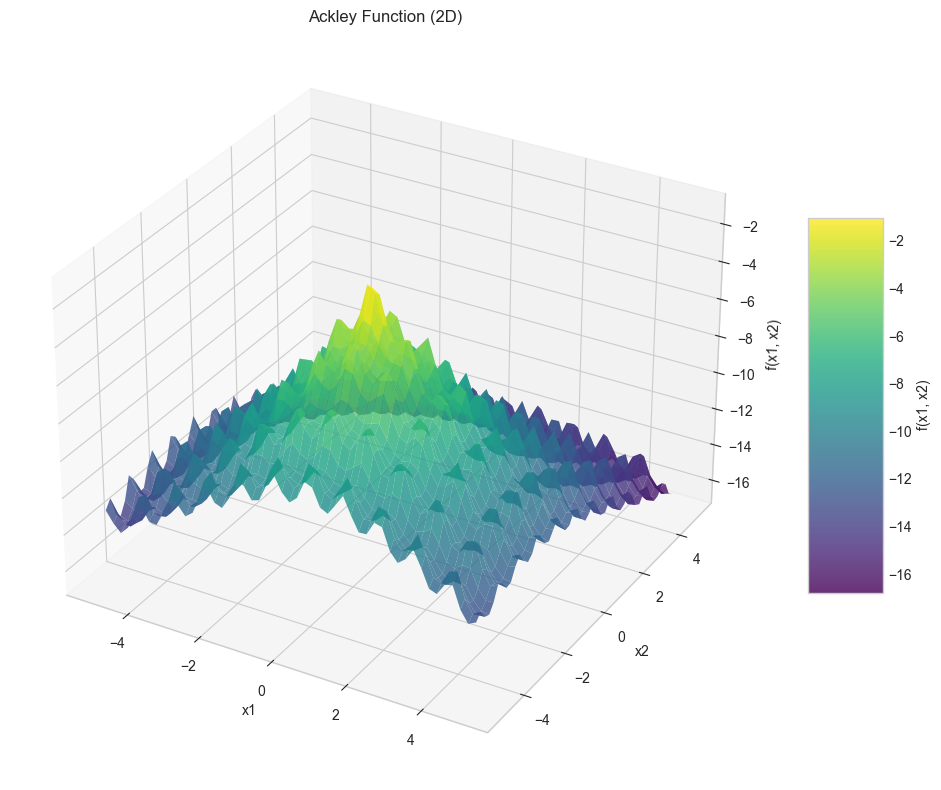

1 [-5.0, 5.0]


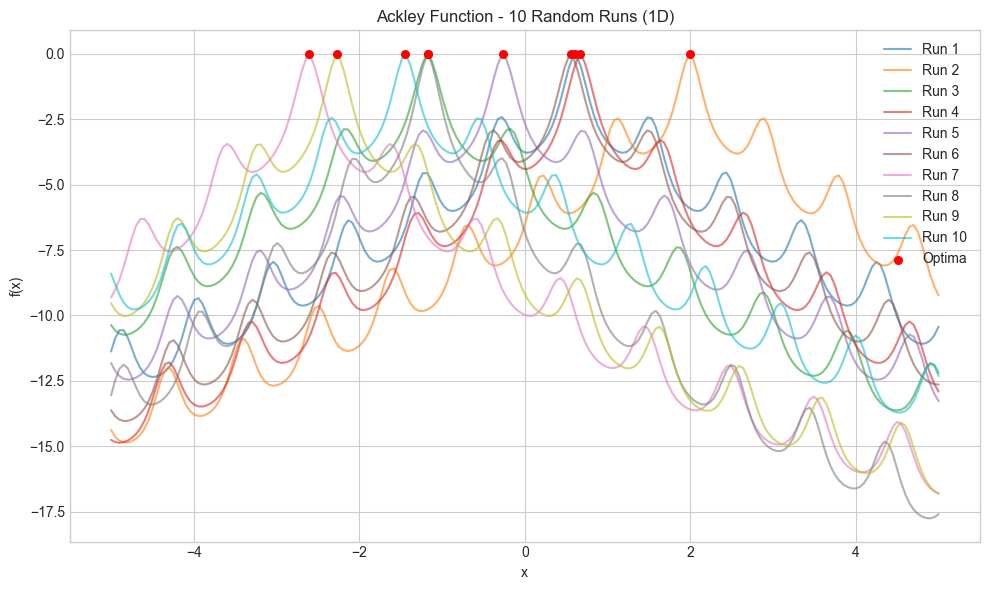

In [4]:
ackley_specific_config = {
    "a_bounds": [18.0, 20.0],
    "b_bounds": [0.15, 0.25],
    "c_bounds": [6.0, 7.0]  # Approx 2*pi
}

ackley_config_1d = {**base_config_1d, **ackley_specific_config}
ackley_config_2d = {**base_config_2d, **ackley_specific_config}

print("\n--- Visualizing Ackley Function ---")

# Plot a single 1D instance (with seed for reproducibility)
plot_sampler_instance(AckleySampler, ackley_config_1d, "Ackley Function", resolution=200, seed=42)

# Plot a single 2D instance (with seed for reproducibility)
plot_sampler_instance(AckleySampler, ackley_config_2d, "Ackley Function", resolution=50, seed=42)

# Plot multiple random 1D instances
plot_multiple_sampler_runs(AckleySampler, ackley_config_1d, "Ackley Function", num_runs=10, resolution=200)

{'action_dim': 1, 'bounds': [-5.0, 5.0], 'num_oscillations': 0, 'A_bounds': [5.0, 10.0], 'B_bounds': [1.0, 2.0], 'small_A_bounds': [0.2, 3.0], 'small_B_bounds': [0.5, 4.0], 'c_bounds': [1.0, 5.0]}
1 [-5.0, 5.0]
Initialized CosineSampler: Optimum=[[0.46183292]], MinY=-2.645, MaxY=10.217


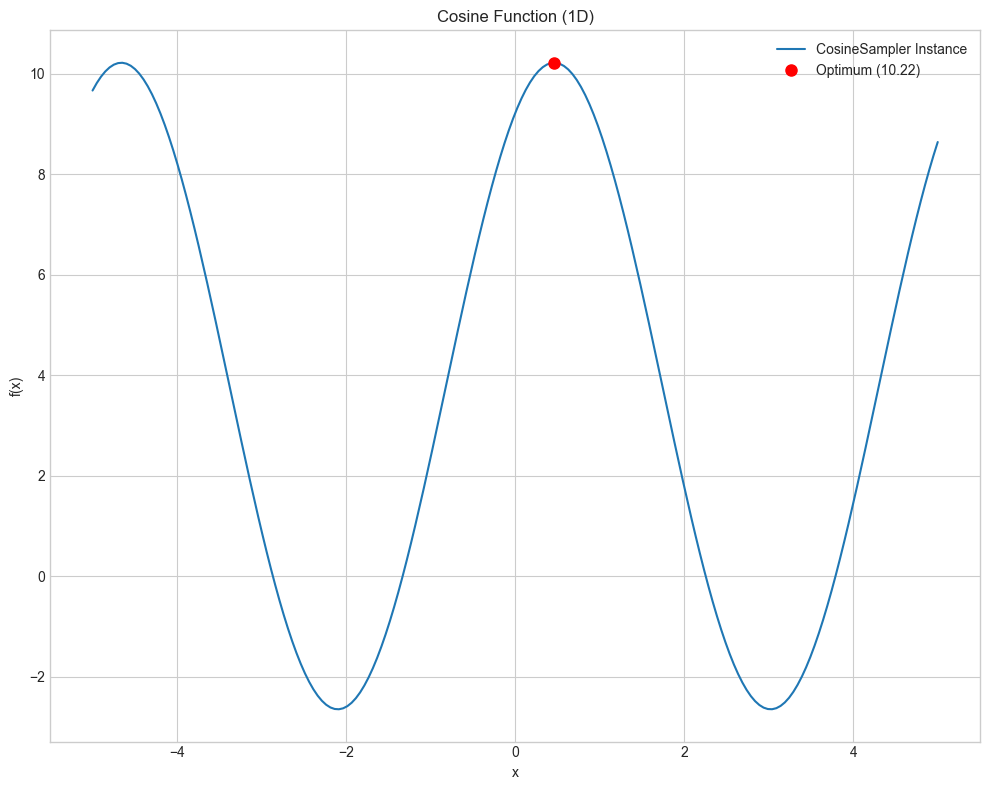

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'action_dim': 2, 'bounds': [-5.0, 5.0], 'num_oscillations': 0, 'A_bounds': [5.0, 10.0], 'B_bounds': [1.0, 2.0], 'small_A_bounds': [0.2, 3.0], 'small_B_bounds': [0.5, 4.0], 'c_bounds': [1.0, 5.0]}
2 [-5.0, 5.0]
Initialized CosineSampler: Optimum=[[ 1.97522073 -0.69204186]], MinY=-9.076, MaxY=16.647


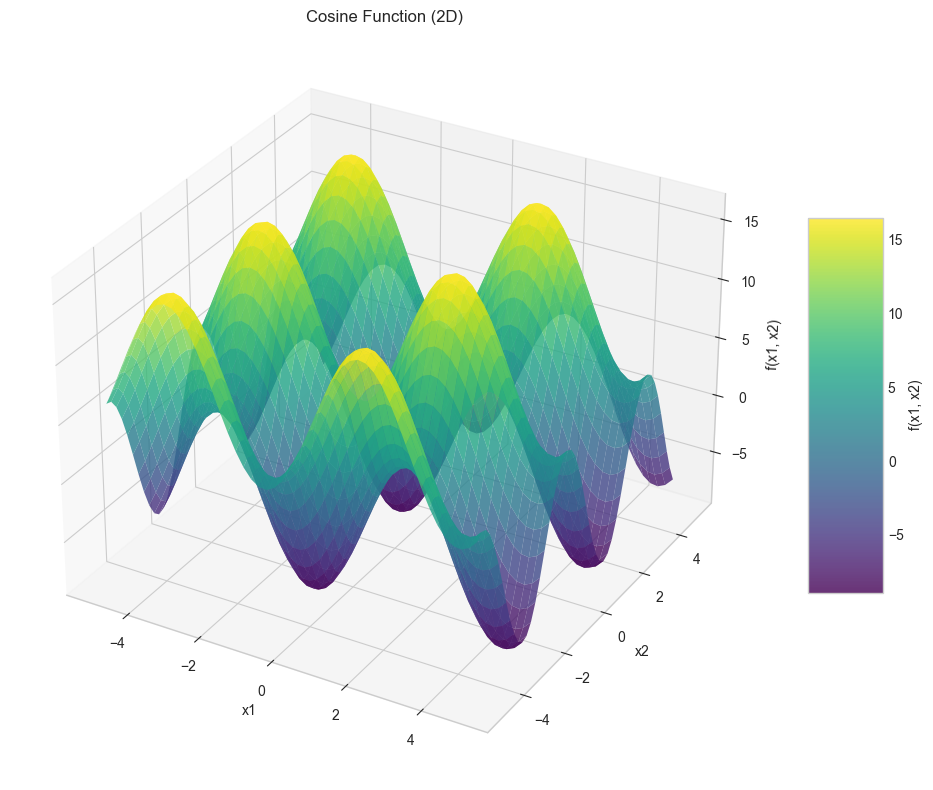

1 [-5.0, 5.0]


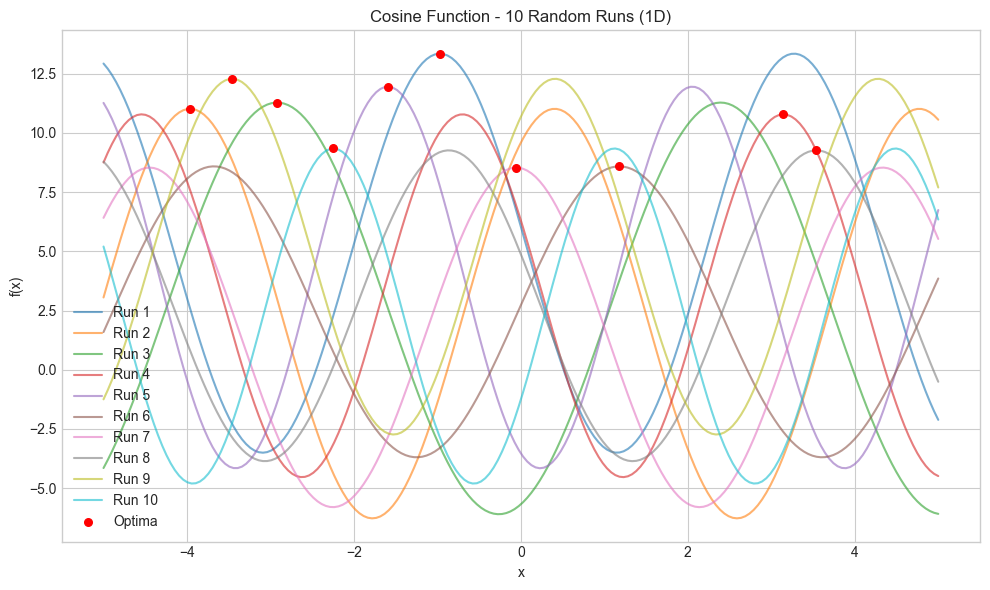

In [5]:
cosine_specific_config = {
    "num_oscillations": 0,
    "A_bounds": [5.0, 10.0],
    "B_bounds": [1.0, 2.0],
    "small_A_bounds": [0.2, 3.0],
    "small_B_bounds": [0.5, 4.0],
    "c_bounds": [1.0, 5.0]
}

cosine_config_1d = {**base_config_1d, **cosine_specific_config}
cosine_config_2d = {**base_config_2d, **cosine_specific_config}

# Plot a single 1D instance
plot_sampler_instance(CosineSampler, cosine_config_1d, "Cosine Function", resolution=200, seed=123)

# Plot a single 2D instance
plot_sampler_instance(CosineSampler, cosine_config_2d, "Cosine Function", resolution=50, seed=123)

# Plot multiple random 1D instances
plot_multiple_sampler_runs(CosineSampler, cosine_config_1d, "Cosine Function", num_runs=10, resolution=200)

{'action_dim': 1, 'bounds': [-5.0, 5.0], 'degree': 2, 'c_bounds': [5.0, 10.0], 'weight_bounds': [0.5, 1.5]}
1 [-5.0, 5.0]
Initialized PolySampler: Optimum=[[2.92945657]], MinY=-53.765, MaxY=8.361


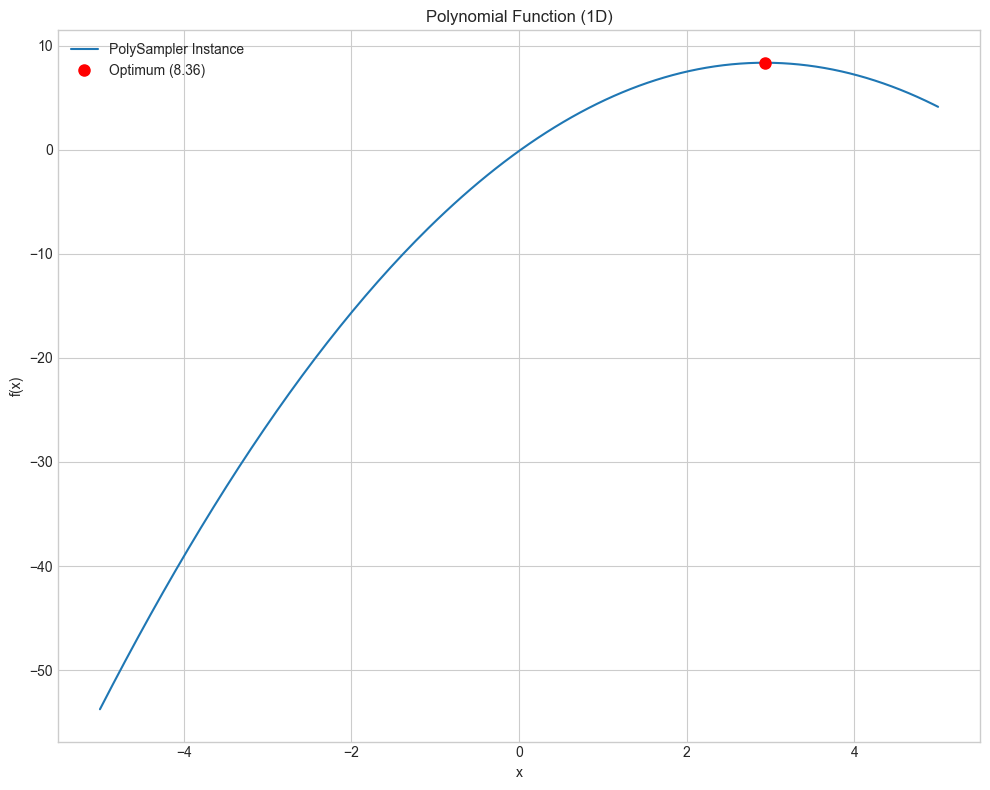

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'action_dim': 2, 'bounds': [-5.0, 5.0], 'degree': 2, 'c_bounds': [5.0, 10.0], 'weight_bounds': [0.5, 1.5]}
2 [-5.0, 5.0]
Initialized PolySampler: Optimum=[[-4.21698251  2.77244967]], MinY=-155.653, MaxY=8.361


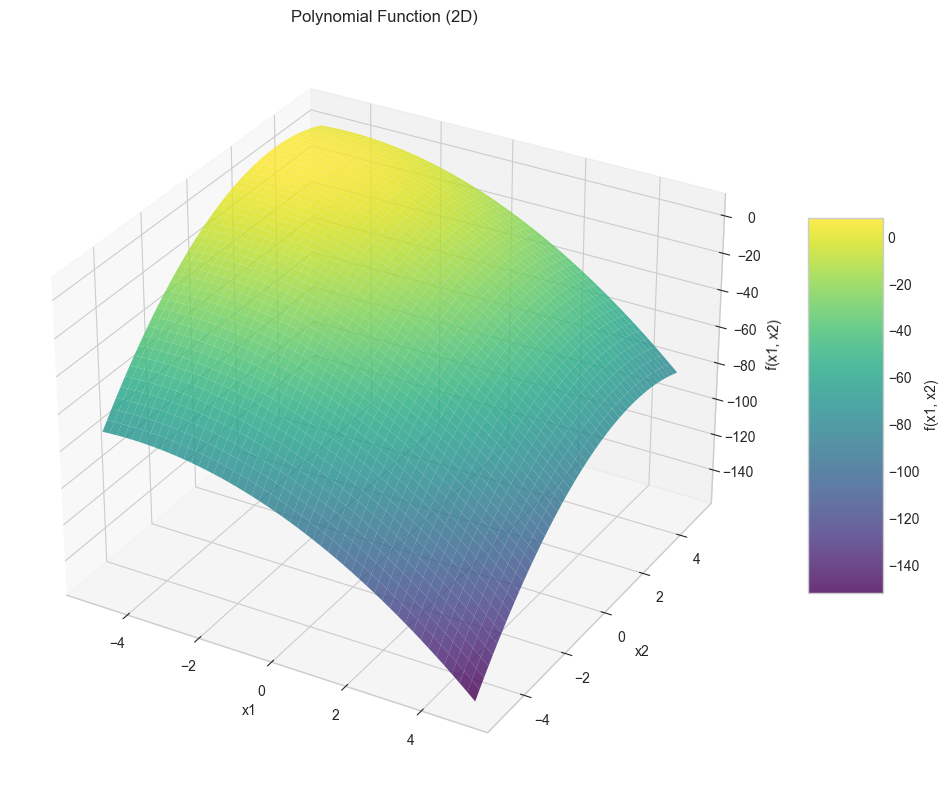

1 [-5.0, 5.0]


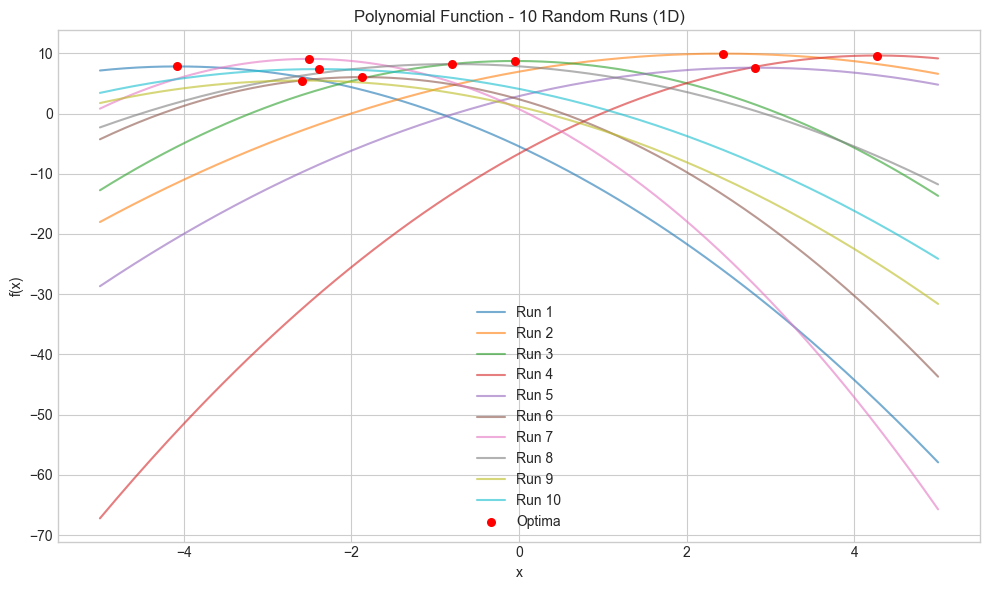

In [6]:
poly_specific_config = {
    "degree": 2, # Use an even degree for clear maximum
    "c_bounds": [5.0, 10.0],
    "weight_bounds": [0.5, 1.5]
}

poly_config_1d = {**base_config_1d, **poly_specific_config}
poly_config_2d = {**base_config_2d, **poly_specific_config}

# Plot a single 1D instance
plot_sampler_instance(PolySampler, poly_config_1d, "Polynomial Function", resolution=200, seed=99)

# Plot a single 2D instance
plot_sampler_instance(PolySampler, poly_config_2d, "Polynomial Function", resolution=50, seed=99)

# Plot multiple random 1D instances
plot_multiple_sampler_runs(PolySampler, poly_config_1d, "Polynomial Function", num_runs=10, resolution=200)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'action_dim': 2, 'bounds': [-512, 512]}
2 [-512, 512]
EggholderSamplerND initialized with min_y: -1049.0, max_y: 959.6407, [512.     404.2319]
Initialized EggholderSamplerND: Optimum=[[512.     404.2319]], MinY=-1049.000, MaxY=959.641


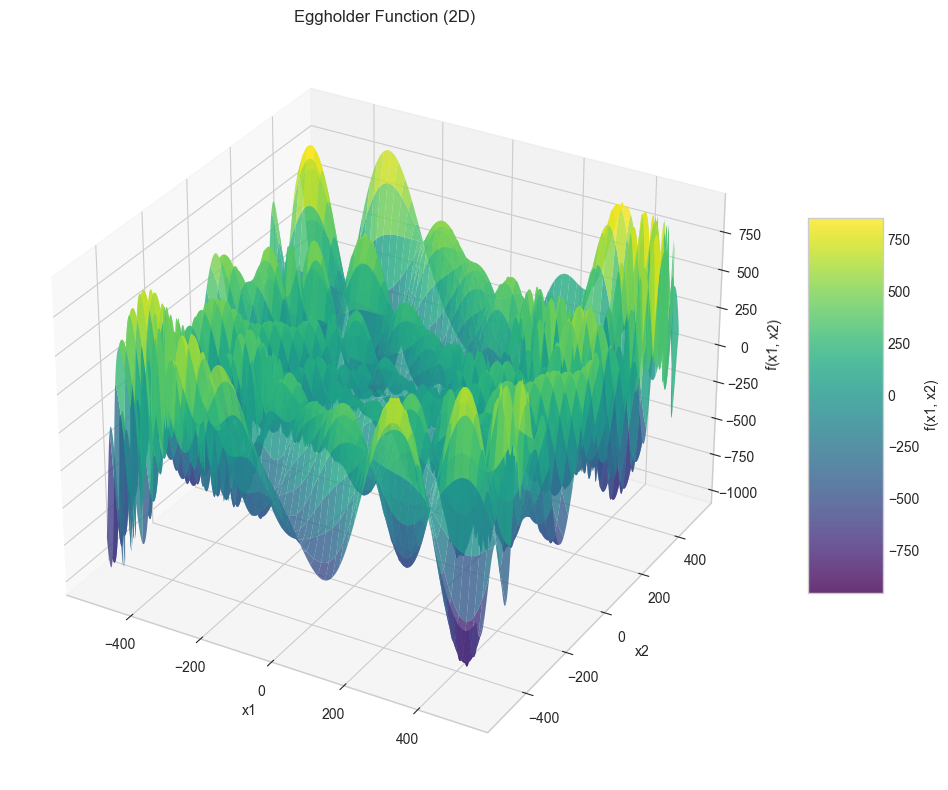

In [7]:
egg_specific_config = {
    "bounds": [-512, 512]
}

egg_1d = {**base_config_1d}
egg2d = {**base_config_2d, **egg_specific_config}

# Plot a single 1D instance
# plot_sampler_instance(EggholderSamplerND, egg_1d, "Eggholder Function", resolution=200, seed=99)

# Plot a single 2D instance
plot_sampler_instance(EggholderSamplerND, egg2d, "Eggholder Function", resolution=500, seed=99)

# Plot multiple random 1D instances
# plot_multiple_sampler_runs(EggholderSamplerND, egg_1d, "Eggholder Function", num_runs=10, resolution=200)

{'action_dim': 2, 'bounds': [0, 3.141592653589793]}
2 [0, 3.141592653589793]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Initialized MichalewiczSampler: Optimum=[[2.20446091 1.56922396]], MinY=0.000, MaxY=1.801


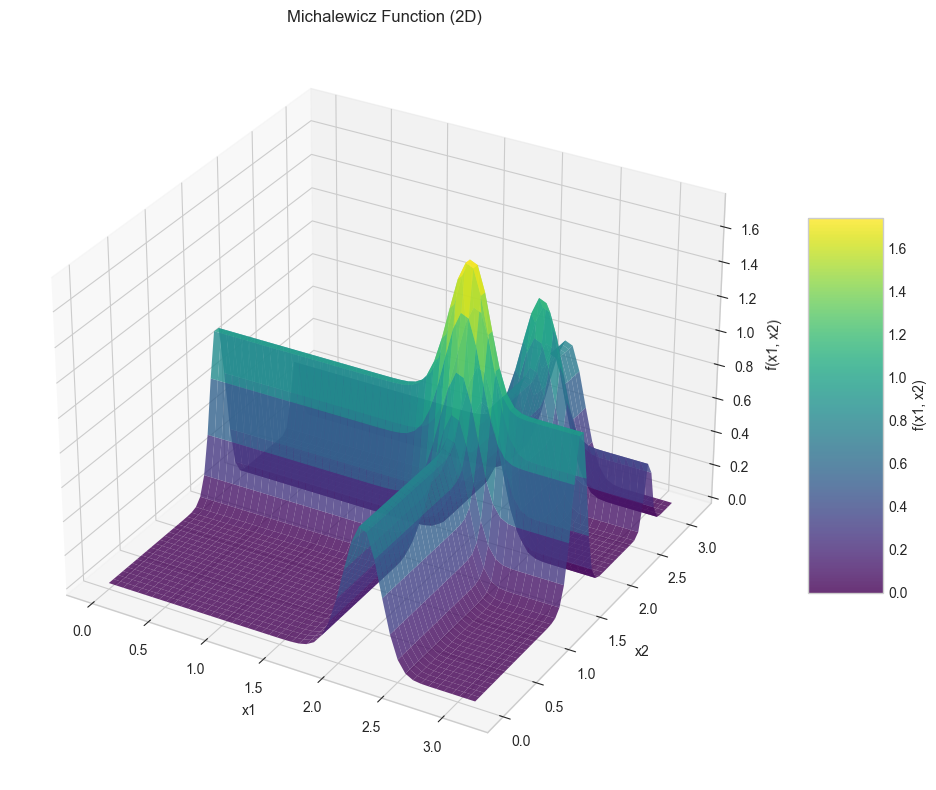

In [8]:
micheal_specific_config = {
    "bounds": [0, math.pi],
    "action_dim": 2,  # Michalewicz is typically 2D
}

micheal_config_2d = {**base_config_2d, **micheal_specific_config}
plot_sampler_instance(MichalewiczSampler, micheal_config_2d, "Michalewicz Function", resolution=50, seed=99)

{'action_dim': 1, 'bounds': [-5.0, 5.0]}
1 [-5.0, 5.0]
Initialized RosenbrockSampler: Optimum=[[1.]], MinY=-0.000, MaxY=0.000


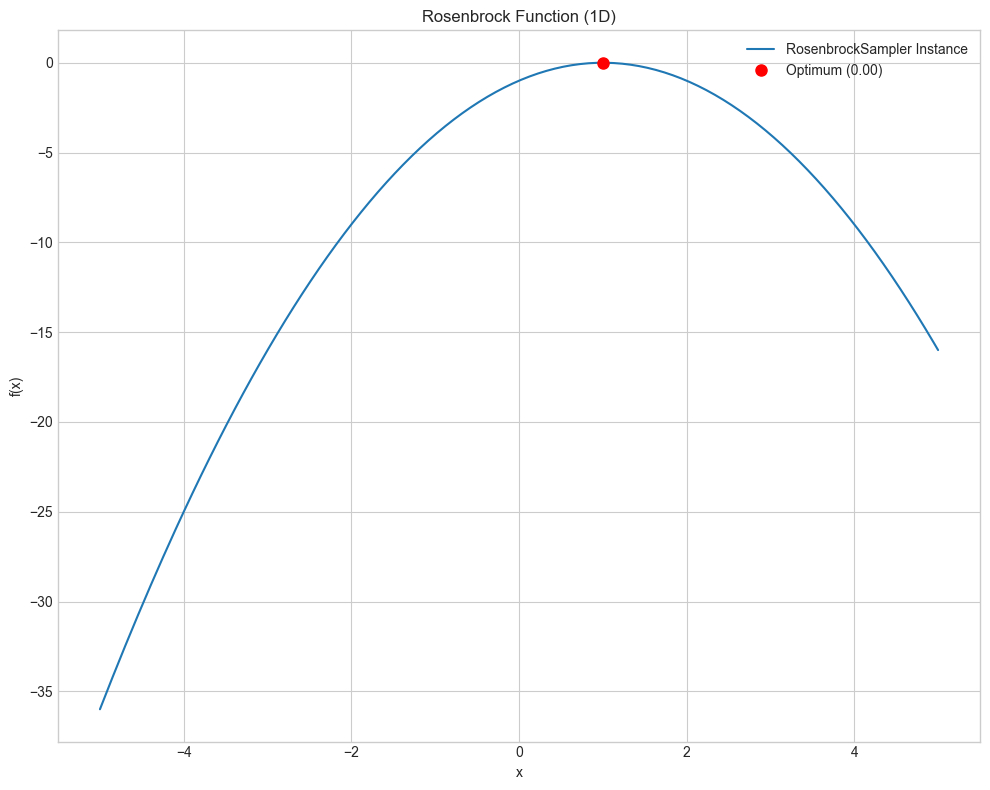

{'action_dim': 2, 'bounds': [-5.0, 5.0]}
2 [-5.0, 5.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Initialized RosenbrockSampler: Optimum=[[1. 1.]], MinY=-1102581.000, MaxY=-0.000


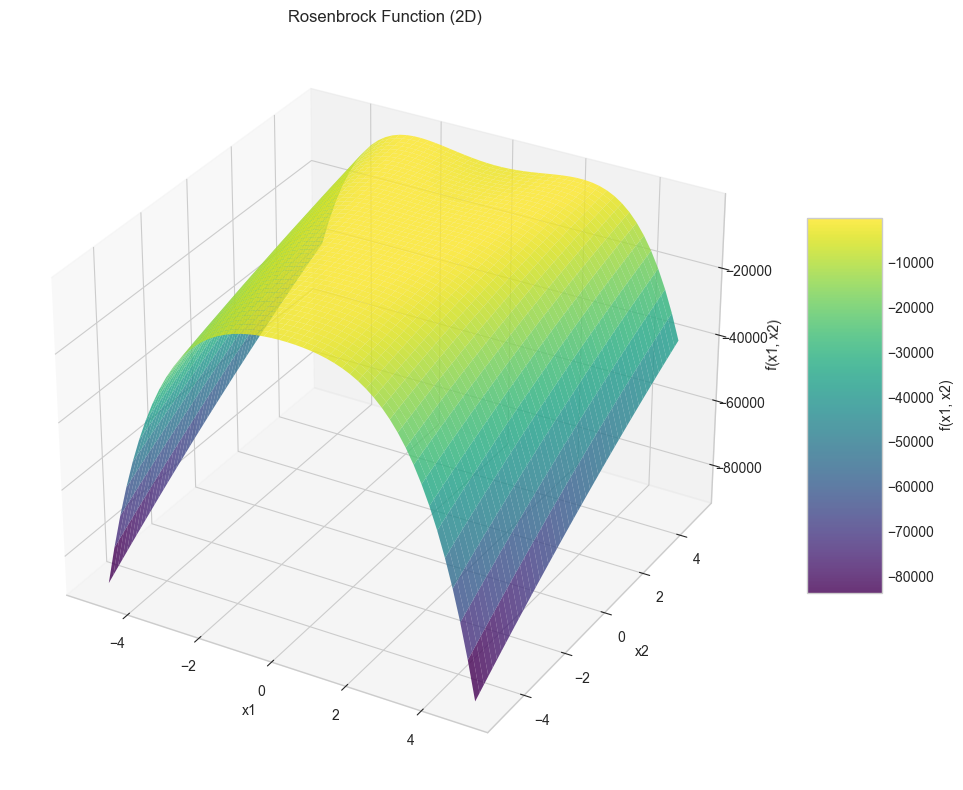

1 [-5.0, 5.0]


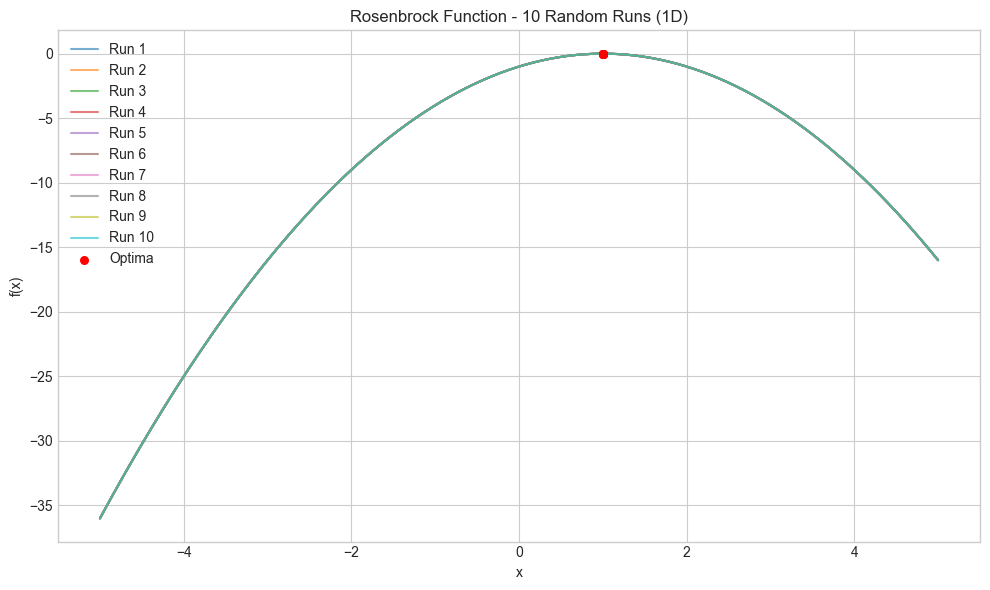

In [9]:
rosen_specific_config = {
    # "bounds": [-10, 10],
    # "action_dim": 4,  # Rosenbrock is typically 2D
}

rosen_config_1d = {**base_config_1d, **rosen_specific_config}
rosen_config_2d = {**base_config_2d, **rosen_specific_config}

plot_sampler_instance(RosenbrockSampler, rosen_config_1d, "Rosenbrock Function", resolution=200, seed=99)
plot_sampler_instance(RosenbrockSampler, rosen_config_2d, "Rosenbrock Function", resolution=50, seed=99)

plot_multiple_sampler_runs(RosenbrockSampler, rosen_config_1d, "Rosenbrock Function", num_runs=10, resolution=200)


{'action_dim': 2, 'bounds': [-5.0, 5.0], 'a': 1.0, 'b': 0.12918450914398066, 'c': 1.5915494309189535, 'r': 6.0, 's': 10.0, 't': 0.039788735772973836}
{'action_dim': 2, 'bounds': [-5.0, 5.0], 'a': 1.0, 'b': 0.12918450914398066, 'c': 1.5915494309189535, 'r': 6.0, 's': 10.0, 't': 0.039788735772973836}
2 [-5.0, 5.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Initialized BraninSampler: Optimum=[[-3.14159265 12.275     ]], MinY=-308.129, MaxY=-0.398


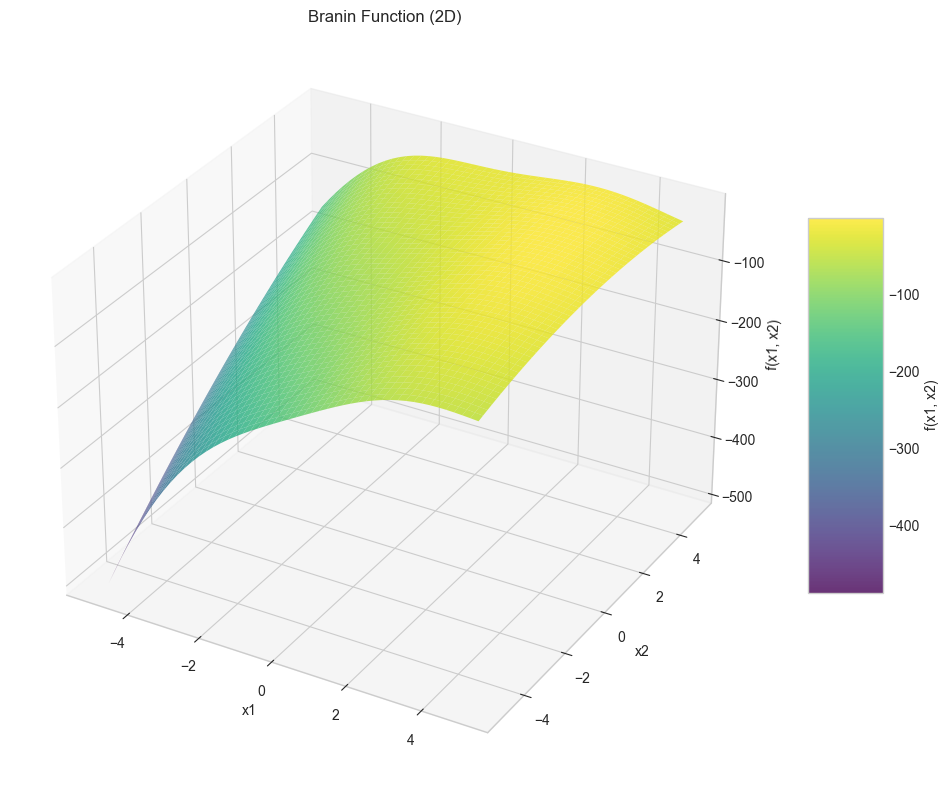

In [10]:
branin_specific_config = {
    # "bounds": [-15, 15],

    "a": 1.0,
    "b": 5.1 / (4 * math.pi**2),
    "c": 5 / math.pi,
    "r": 6.0,
    "s": 10.0,
    "t": 1 / (8 * math.pi),
    
    
}

branin_config_2d = {**base_config_2d, **branin_specific_config}
print(branin_config_2d)

plot_sampler_instance(BraninSampler, branin_config_2d, "Branin Function", resolution=50, seed=99)

In [11]:
matter_specific_config = {
    "bounds": [0, 1],
    "action_dim": 6,
}

hart_6d = {**base_config_1d, **matter_specific_config}

plot_sampler_instance(Hartmann6Sampler, hart_6d, "GPsampler Function", resolution=200, seed=99)

{'action_dim': 6, 'bounds': [0, 1]}
6 [0, 1]
Initialized Hartmann6Sampler: Optimum=[[1. 1. 0. 1. 1. 1.]], MinY=-3.322, MaxY=-3.322
Plotting only supported for 1D and 2D. Skipping plot for dim=6.


{'action_dim': 1, 'bounds': [-5.0, 5.0], 'length_scale': 5.0, 'sigma_f': 1.0, 'sigma_n': 1, 'points_per_dim': 10}
1 [-5.0, 5.0]
Initialized GPSampler: Optimum=[[-1.66666667]], MinY=-1.889, MaxY=2.465


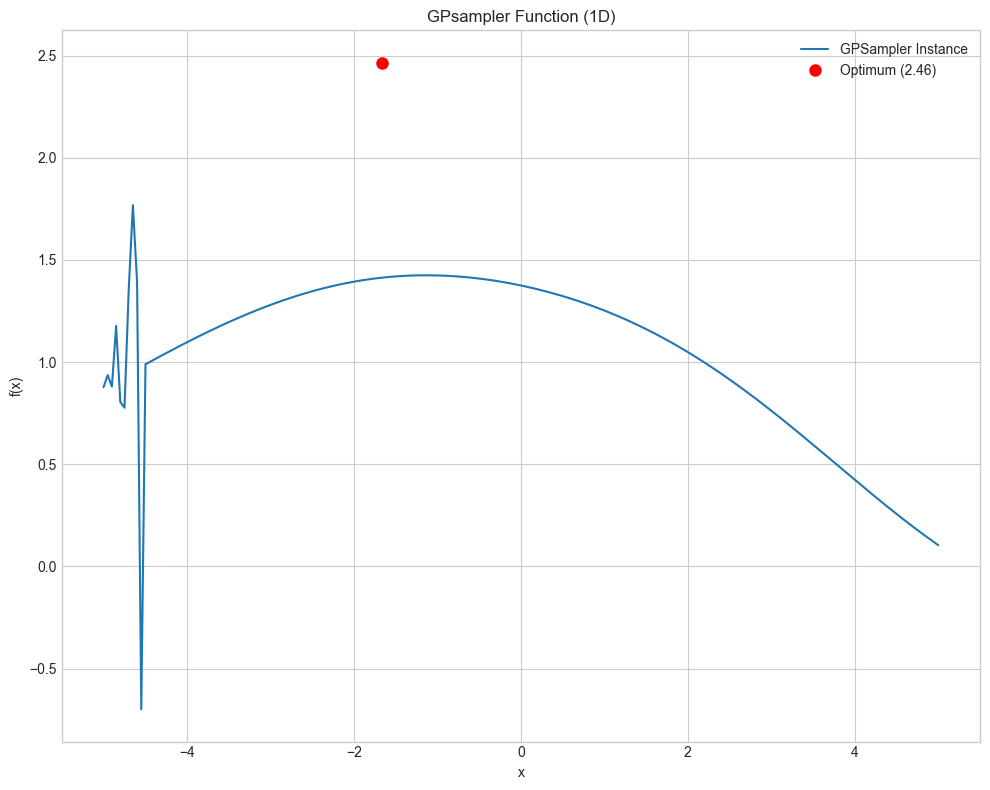

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'action_dim': 2, 'bounds': [-5.0, 5.0], 'length_scale': 5.0, 'sigma_f': 1.0, 'sigma_n': 1, 'points_per_dim': 10}
2 [-5.0, 5.0]
Initialized GPSampler: Optimum=[[-2.77777778 -1.66666667]], MinY=-2.254, MaxY=3.010


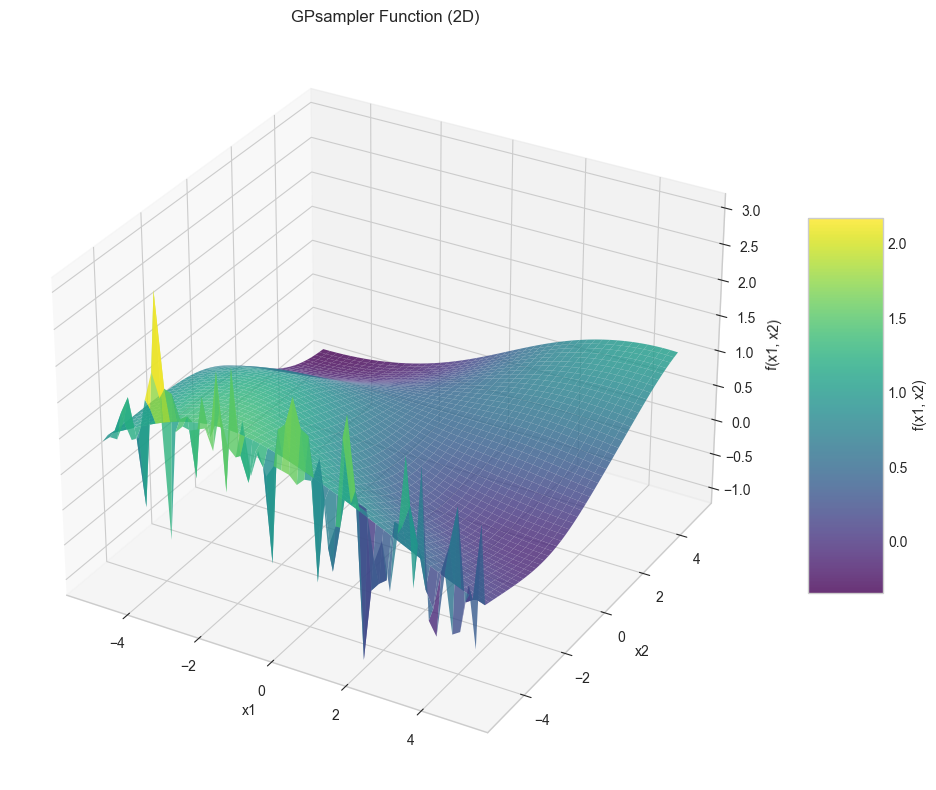

1 [-5.0, 5.0]


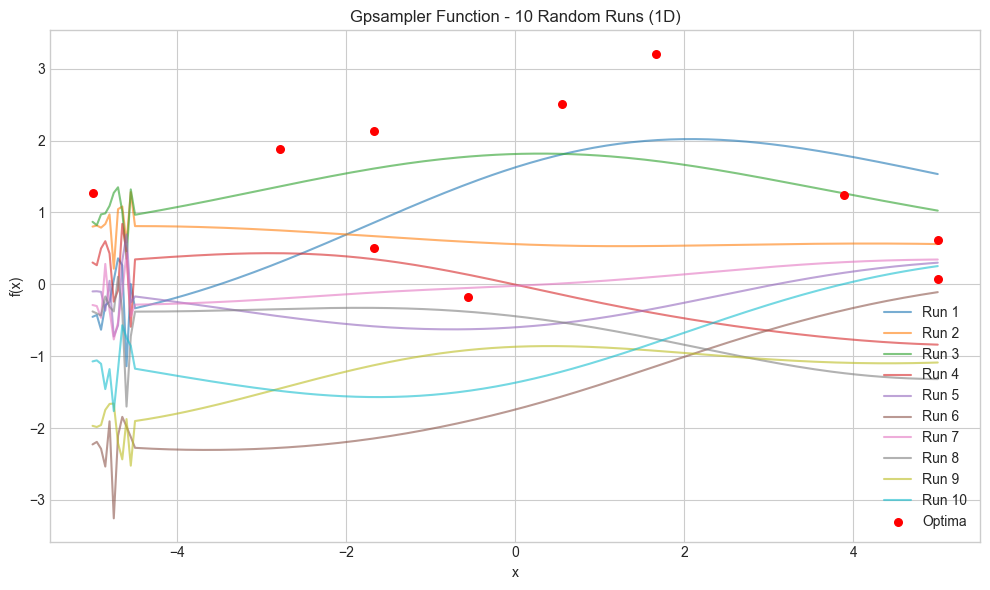

In [13]:
matter_specific_config = {
    "length_scale": 5.0, # Use an even degree for clear maximum
    "sigma_f": 1.0,
    "sigma_n": 1,
    "points_per_dim": 10,
}

matter_config_1d = {**base_config_1d, **matter_specific_config}
matter_config_2d = {**base_config_2d, **matter_specific_config}

# Plot a single 1D instance
plot_sampler_instance(GPSampler, matter_config_1d, "GPsampler Function", resolution=200, seed=99)

# Plot a single 2D instance
plot_sampler_instance(GPSampler, matter_config_2d, "GPsampler Function", resolution=50, seed=99)

# Plot multiple random 1D instances
plot_multiple_sampler_runs(GPSampler, matter_config_1d, "Gpsampler Function", num_runs=10, resolution=200)